In [24]:
import torch
import os
import glob
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
import numpy as np
import matplotlib.pyplot as plt
import torchvision.transforms as T
import matplotlib.pyplot as plt
import PIL
from PIL import Image

In [14]:
class Gaussian(object):
    def __init__(self, mean: float, var: float):
        self.mean = mean
        self.var = var
    def __call__(self, img: torch.Tensor) -> torch.Tensor:
        return img + torch.normal(self.mean, self.var, img.size())
# preprocess = T.Compose([
# T.ToTensor(),
# T.RandomHorizontalFlip(),
# T.RandomRotation(45),
# Gaussian(0,0.15),
# ])

preprocess = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize images to a fixed size
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),  # Normalizing based on ImageNet statistics
])

In [19]:
class MyDataset(Dataset):
    def __init__(self, transform=None, str="train"):
        self.imgs_path = os.path.join("..", "data", "cats_and_dogs_filtered", str)
        file_list = glob.glob(os.path.join(self.imgs_path, "*"))
        self.data = []
        for class_path in file_list:
            if os.path.isdir(class_path):  
                class_name = os.path.basename(class_path)
                print(f"Processing class: {class_name}")
                for img_path in glob.glob(os.path.join(class_path, "*.jpg")):
                    self.data.append([img_path, class_name])

        self.class_map = {"dogs": 0, "cats": 1}
        self.transform = transform if transform else transforms.Compose([
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        img_path, class_name = self.data[idx]
        img = PIL.Image.open(img_path)
        class_id = self.class_map[class_name]
        class_id = torch.tensor(class_id)
        if self.transform:
            img = self.transform(img)
        return img, class_id
dataset = MyDataset(transform=preprocess,str = "train")
train_dataloader = DataLoader(MyDataset(transform=preprocess,str = "train"))
test_loader = DataLoader(MyDataset(transform=preprocess,str = "Validation"))



Processing class: cats
Processing class: dogs
Processing class: cats
Processing class: dogs


torch.Size([1, 3, 224, 224])


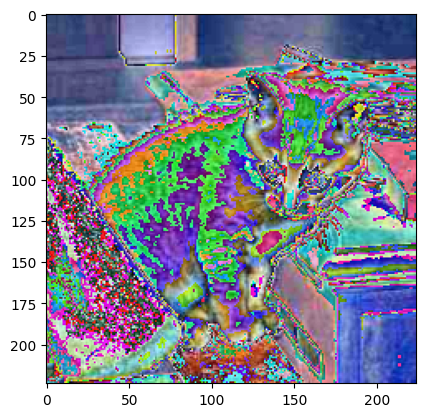

torch.Size([1, 3, 224, 224])


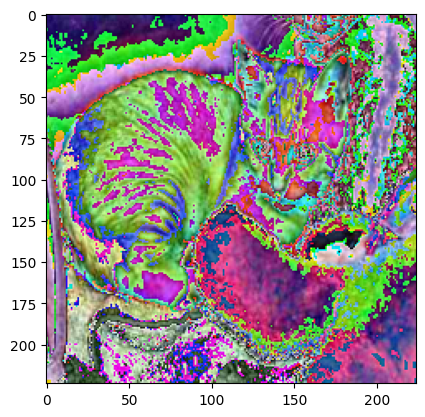

torch.Size([1, 3, 224, 224])


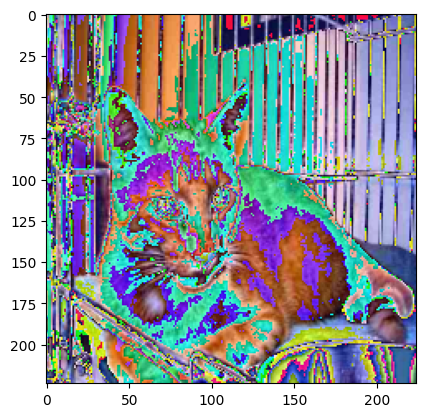

In [22]:
i=0
for data in iter(train_dataloader):
    img,_ = data
    print(img.shape)
    tI = T.ToPILImage()
    img = tI(img.squeeze())
    plt.imshow(img)
    plt.show()
    i = i + 1
    if i == 3:
        break

Question1) Implement L2 regularization on cat-dog classification neural network. Train the model on the
dataset, and observe the impact of the regularization on the weight parameters. (Do not use
data augmentation).

a. L2 regularization using optimizer’s weight decay<br>
b. L2 regularization using loop to find L2 norm of weights

In [25]:
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Data transforms (you can modify these)
transform = transforms.Compose([
    transforms.Resize((128, 128)),  # Resize to fit our model's expected input
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Pretrained model's means and stds
])

# Load data
train_dataset = torchvision.datasets.ImageFolder(root='../data/cats_and_dogs_filtered/train', transform=transform)
test_dataset = torchvision.datasets.ImageFolder(root='../data/cats_and_dogs_filtered/validation', transform=transform)

train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)


In [26]:
class CatsDogsCNN(nn.Module):
    def __init__(self):
        super(CatsDogsCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 16 * 16, 512)  # after pooling layers
        self.fc2 = nn.Linear(512, 2)  # 2 classes: Cat and Dog
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.pool(self.relu(self.conv3(x)))
        x = x.view(-1, 64 * 16 * 16)  # Flatten
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x


In [27]:
def train_and_evaluate(model, train_loader, test_loader, criterion, optimizer, epochs=5):
    model.to(device)
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        # Training loop
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        epoch_loss = running_loss / len(train_loader)
        epoch_acc = 100 * correct / total
        print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}%")
        
    return model


In [34]:

def evaluate_model(model):
    model.eval()  
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f"Test Accuracy: {accuracy:.2f}%")
    return accuracy

In [28]:
# L2 Regularization using weight decay
def train_with_weight_decay():
    model = CatsDogsCNN().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=0.01)  # L2 Regularization

    print("Training with Weight Decay (L2 Regularization)")
    return train_and_evaluate(model, train_dataloader, test_dataloader, criterion, optimizer)


In [35]:
l2_weight_decay_model = train_with_weight_decay()
evaluate_model(l2_weight_decay_model)


Training with Weight Decay (L2 Regularization)
Epoch 1/5, Loss: 0.7131, Accuracy: 51.35%
Epoch 2/5, Loss: 0.6865, Accuracy: 55.40%
Epoch 3/5, Loss: 0.6588, Accuracy: 59.00%
Epoch 4/5, Loss: 0.6529, Accuracy: 59.80%
Epoch 5/5, Loss: 0.6355, Accuracy: 60.75%
Test Accuracy: 59.60%


59.6

In [29]:
# L2 Regularization using loop to compute the L2 norm
def train_with_explicit_l2():
    model = CatsDogsCNN().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    lambda_l2 = 0.01  # L2 regularization strength

    def l2_norm(model):
        l2_reg = torch.tensor(0.).to(device)
        for param in model.parameters():
            if param.requires_grad:
                l2_reg += torch.norm(param, p=2) ** 2
        return l2_reg

    def regularized_loss(loss, model, lambda_l2):
        return loss + lambda_l2 * l2_norm(model)

    print("Training with Explicit L2 Regularization")
    model.train()
    running_loss = 0.0
    for epoch in range(5):
        for images, labels in train_dataloader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            base_loss = criterion(outputs, labels)
            loss = regularized_loss(base_loss, model, lambda_l2)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        print(f"Epoch {epoch+1}/5, Loss: {running_loss / len(train_dataloader):.4f}")
    
    return model


In [36]:
# Train the model with explicit L2 regularization using a loop
l2_explicit_model = train_with_explicit_l2()

# Evaluate the model
evaluate_model(l2_explicit_model)


Training with Explicit L2 Regularization
Epoch 1/5, Loss: 1.1897
Epoch 2/5, Loss: 2.0075
Epoch 3/5, Loss: 2.7776
Epoch 4/5, Loss: 3.5226
Epoch 5/5, Loss: 4.2454
Test Accuracy: 59.10%


59.1

In [38]:
# # Run both experiments
# print("=== Experiment a: L2 Regularization with Weight Decay ===")
# wd_magnitudes = train_with_weight_decay()

# print("\n=== Experiment b: L2 Regularization with Explicit Loop ===")
# explicit_magnitudes = train_with_explicit_l2()

# # Compare results
# print("\n=== Comparison ===")
# print("Weight Decay Magnitudes:", [f"{x:.6f}" for x in wd_magnitudes])
# print("Explicit L2 Magnitudes:", [f"{x:.6f}" for x in explicit_magnitudes])


Evaluating L2 Regularization via Optimizer's Weight Decay:
Test Accuracy: 59.60%
Evaluating L2 Regularization via Manual Norm Calculation:
Test Accuracy: 59.10%
Evaluating Dropout Regularization:
Test Accuracy: 71.60%
Test Accuracy: 71.60%


Question 3) Implement dropout regularization on cat-dog classification neural network. Train the model
with and without dropout on a dataset, and compare the performance and overfitting
tendencies.

Question 4) Implement your own version of the dropout layer by using Bernoulli distribution and compare
the performance with the library.

In [31]:
class CatsDogsCNNWithDropout(nn.Module):
    def __init__(self, dropout_rate=0.5):
        super(CatsDogsCNNWithDropout, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 16 * 16, 512)
        self.fc2 = nn.Linear(512, 2)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p=dropout_rate)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.pool(self.relu(self.conv3(x)))
        x = x.view(-1, 64 * 16 * 16)  # Flatten
        x = self.relu(self.fc1(x))
        x = self.dropout(x)  # Dropout applied here
        x = self.fc2(x)
        return x

# Example of using dropout during training
dropout_model = CatsDogsCNNWithDropout(dropout_rate=0.5)
optimizer = optim.Adam(dropout_model.parameters(), lr=0.001)
train_with_weight_decay()  # Same function can be used with dropout


Training with Weight Decay (L2 Regularization)
Epoch 1/5, Loss: 0.6913, Accuracy: 55.30%
Epoch 2/5, Loss: 0.6555, Accuracy: 61.10%
Epoch 3/5, Loss: 0.6315, Accuracy: 62.85%
Epoch 4/5, Loss: 0.6091, Accuracy: 68.90%
Epoch 5/5, Loss: 0.5873, Accuracy: 68.70%


CatsDogsCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=16384, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=2, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.5, inplace=False)
)

In [41]:
# Train the model with Dropout Regularization
dropout_model = CatsDogsCNNWithDropout(dropout_rate=0.0).to(device)
optimizer = optim.Adam(dropout_model.parameters(), lr=0.001)

# Train with dropout
train_and_evaluate(dropout_model, train_dataloader, test_dataloader, nn.CrossEntropyLoss(), optimizer)

# Evaluate the model with Dropout Regularization
evaluate_model(dropout_model)


Epoch 1/5, Loss: 0.7341, Accuracy: 55.90%
Epoch 2/5, Loss: 0.6298, Accuracy: 65.95%
Epoch 3/5, Loss: 0.5480, Accuracy: 71.95%
Epoch 4/5, Loss: 0.4873, Accuracy: 77.60%
Epoch 5/5, Loss: 0.4063, Accuracy: 81.60%
Test Accuracy: 67.20%


67.2

In [37]:
# Train the model with Dropout Regularization
dropout_model = CatsDogsCNNWithDropout(dropout_rate=0.5).to(device)
optimizer = optim.Adam(dropout_model.parameters(), lr=0.001)

# Train with dropout
train_and_evaluate(dropout_model, train_dataloader, test_dataloader, nn.CrossEntropyLoss(), optimizer)

# Evaluate the model with Dropout Regularization
evaluate_model(dropout_model)


Epoch 1/5, Loss: 0.7043, Accuracy: 55.55%
Epoch 2/5, Loss: 0.6314, Accuracy: 64.75%
Epoch 3/5, Loss: 0.5567, Accuracy: 71.60%
Epoch 4/5, Loss: 0.4986, Accuracy: 75.80%
Epoch 5/5, Loss: 0.4306, Accuracy: 80.20%
Test Accuracy: 71.60%


71.6

Question 5) Implement early stopping as a form of regularization. Train a neural network and monitor the
validation loss. Stop training when the validation loss starts increasing, and compare the
performance with a model trained without early stopping.

In [8]:
class EarlyStopping:
    def __init__(self, patience=3, delta=0):
        self.patience = patience
        self.delta = delta
        self.best_loss = float('inf')
        self.epochs_without_improvement = 0
        self.stop_training = False

    def __call__(self, val_loss):
        if val_loss < self.best_loss - self.delta:
            self.best_loss = val_loss
            self.epochs_without_improvement = 0
        else:
            self.epochs_without_improvement += 1
            if self.epochs_without_improvement >= self.patience:
                self.stop_training = True
        return self.stop_training

def train_with_early_stopping():
    early_stopping = EarlyStopping(patience=3)

    model = CatsDogsCNN().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    print("Training with Early Stopping")
    for epoch in range(20):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_dataloader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_loss = running_loss / len(train_dataloader)
        epoch_acc = 100 * correct / total
        print(f"Epoch {epoch+1}/20, Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}%")

        val_loss = evaluate_on_validation_set(model)  # Replace with validation set logic
        if early_stopping(val_loss):
            print("Early stopping triggered!")
            break


In [39]:
def evaluate_on_validation_set(model):
    model.eval()  
    correct = 0
    total = 0
    for images, labels in test_dataloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    return accuracy

train_with_early_stopping()



Training with Early Stopping
Epoch 1/20, Loss: 0.6982, Accuracy: 52.55%
Epoch 2/20, Loss: 0.6562, Accuracy: 62.75%
Epoch 3/20, Loss: 0.6050, Accuracy: 68.55%
Epoch 4/20, Loss: 0.5312, Accuracy: 74.65%
Early stopping triggered!
